# Proposed Discussion section

A draft expanding the manuscript's Discussion, which currently has an opening paragraph and three
placeholders — *[discussion of how companies can do this with SOC]*, *[discussion of results
from erosion and implications for target-setting]*, *[discussion of where this moves acidification,
even though it's already more developed]* — plus a closing paragraph on scaling/API.

The draft is organised as: (1) what LEAFs enable, (2) SOC, (3) soil erosion, (4) terrestrial
acidification, (5) the multi-indicator / spatial-aggregation insight, (6) limitations &
uncertainty, (7) outlook. Numbers come from the manuscript's own Results and the companion
`claude_analysis` notebooks; **bracketed italics flag claims the authors should confirm** or that
depend on re-running flagged models.

## Discussion (draft)

### From global proxies to ecoregional decision factors

The development of Land Environmental Assessment Factors (LEAFs) provides a mid-scale,
ecoregionally-resolved quantification of how land use and management changes move three key land
quality indicators — soil organic carbon (SOC), soil erosion and terrestrial acidification. By
expressing SOC and erosion as the **absolute state** attainable under a given land use (rather than
as a differential impact against a contested reference state), LEAFs are directly comparable with
the SBTN ecoregional thresholds, closing a gap that has kept conventional LCA characterization
factors out of corporate land target-setting. Crucially, they require no primary data collection at
production sites: a company needs only the commodity, the management practice, and the coordinates
(hence the ecoregion) of production or sourcing. This operationalizes a persistent need in
corporate sustainability — manageable, replicable, threshold-aligned information on land quality
— while acknowledging that within-ecoregion variability remains, and that site-level measurement
will always refine a LEAF-based estimate.

### Soil organic carbon: quantifying the carbon return on practice change

For SOC, the LEAFs let a company read off the Maximum Attainable SOC stock (MaxSOC) of a candidate
land use in its ecoregion and, because the factors are resolved by management practice, the SOC
consequence of *changing* practice. The practice decomposition shows that **residue retention is
the single largest lever**, followed by irrigation and then tillage, and that stacking the most
beneficial combination (rainfed, residues retained, reduced tillage) against the least beneficial
(irrigated, residues removed, conventional tillage) yields on average **~37–39 % higher SOC after
15 years**. That headline average, however, conceals a wide range *between commodities*: across the
five cereals that carry the full stack it spans a median **+14 % for rapeseed** to **+38 % for
maize** (means +21 % to +54 %), with wheat (+31 %), sorghum (+26 %) and barley (+22 %) in between
(box below). The benefit scales with how residue-responsive a crop's carbon balance is — high-
residue cereals such as maize gain most — so the single ~37.5 % figure is best reported alongside
this commodity range rather than on its own. The ordering is mechanistically coherent — residues
are the dominant fresh-carbon input to RothC, whereas tillage acts more weakly through the
decomposition-rate modifier — giving companies a defensible priority order for regenerative
interventions. Two further nuances matter for use. First, the LEAF is an *attainable* long-run
state under sustained practice; the trajectory to it is gradual (crops show slow SOC depletion
under residue removal but reach equilibrium faster when residues are retained), so SOC claims
should be framed over multi-year horizons rather than annually. Second, because the factors are
land-use-specific, a company can credit the SOC gain of a sourcing or management shift *and* check
the resulting stock against the ecoregional threshold in the same step.

> **Supporting analysis** (the by-commodity range behind the SOC sentence — not for the manuscript
> body). Per region, the % difference is `100·(SOC_best − SOC_worst)/SOC_worst`, where *best* =
> rainfed + residues retained + reduced tillage and *worst* = irrigated + residues removed +
> conventional tillage, summarised across ecoregions for each full-stack cereal.

Could not determine dtype for column 1, falling back to string


,commodity,stack,n_regions,soc_worst_med,soc_best_med,median_pct,mean_pct,p10_pct,p90_pct
0,Maize,irrigation+residue+tillage,663,31.4,43.6,38.5,54.1,9.2,112.9
1,Wheat,irrigation+residue+tillage,546,33.7,42.4,30.7,45.6,8.1,102.8
2,Sorghum,irrigation+residue+tillage,601,28.4,36.3,25.8,39.8,4.4,84.2
3,Barley,irrigation+residue+tillage,511,34.5,40.8,21.9,33.1,4.9,78.9
4,Rapeseed,irrigation+residue+tillage,433,34.9,38.9,13.8,20.8,1.7,50.4


range of medians: 14% (Rapeseed) to 38% (Maize); mean of means 39% (manuscript: 37.5%)


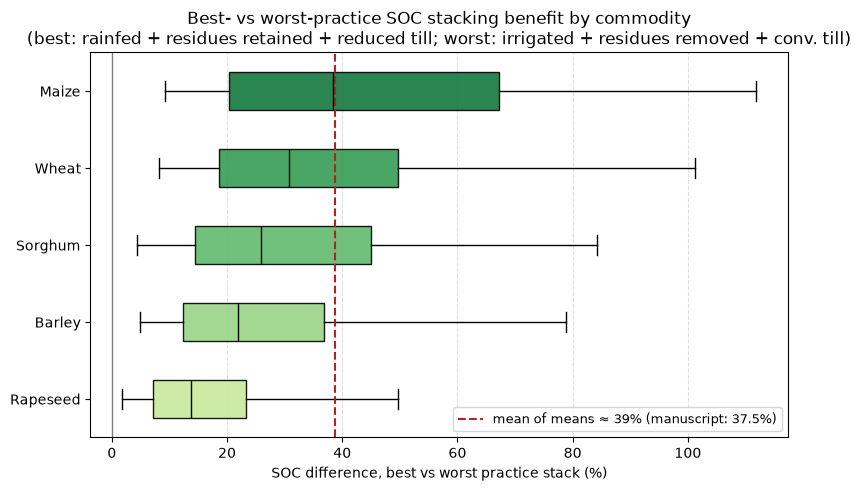

In [1]:
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import matplotlib.pyplot as plt
from sbtn_leaf.claude_analysis import practice_change as pc

tbl = pc.practice_stack_table()  # full-stack cereals, ecoregion level
display(tbl.round(1))
print(f"range of medians: {tbl['median_pct'].min():.0f}% ({tbl.iloc[-1]['commodity']}) "
      f"to {tbl['median_pct'].max():.0f}% ({tbl.iloc[0]['commodity']}); "
      f"mean of means {tbl['mean_pct'].mean():.0f}% (manuscript: 37.5%)")
fig, ax = pc.plot_practice_stack_range(); display(fig); plt.close(fig)

### Soil erosion: hotspot targeting and conservative, transparent multipliers

The RUSLE basis makes the erosion LEAFs especially actionable because management enters
multiplicatively through the cover-management factor *C*: switching residues-removed + conventional
tillage to residues-left + reduced tillage cuts the modelled erosion of a cereal by a **fixed
fraction (~65–77 %) that is independent of location**, while the *absolute* tonnage avoided varies
by up to two orders of magnitude across regions, tracking rainfall erosivity and slope. The
implication for target-setting is twofold: the *relative* benefit of a practice can be communicated
as a single global number per commodity, but **prioritization of where to act must use the absolute
avoided erosion**, which concentrates in the erosive tropics and a few temperate hotspots (eastern
US/Canada, China, south-east Brazil, eastern Africa). Reduced tillage is the main driver of the
reduction across all crops. The assumption *P* = 1 (no support practices) is a deliberate
worst-case: reported LEAFs are upper bounds, so any structural conservation practice a company
applies can only improve on the published factor — a conservative, transparent stance well-suited
to target-setting.

### Terrestrial acidification: a mature CF, newly resolved to the ecoregion

Terrestrial acidification is the most methodologically mature of the three — the LEAF is a
conventional characterization factor (kg SO₂-eq per kg emission) derived from Roy et al. (2014).
The contribution here is therefore less about new modelling and more about **delivering the CF at
the ecoregional resolution SBTN targets require, and showing that ecological structure carries real
signal**: biomes differentiate the CF highly significantly (Kruskal–Wallis p < 0.001 for all three
gases), with the most sensitive biomes — Boreal Forest/Taiga and Deserts & Xeric Shrublands —
reproducing Roy et al. (2012). A two-way decomposition confirms inter-biome variability is at least
as large as inter-gas variability (biome and gas each explain ~0.22 of the log-scale variance; on
the absolute scale biome dominates, median range 8.8× vs 4.9×), so an ecoregional acidification
factor is genuinely more representative than a national one. *[One reconciliation remains for
threshold use: the LEAF is expressed as SO₂-equivalents whereas the ecoregional acidification
threshold is nitrogen-deposition-based; the two must be placed on a common basis before a company
can compare an acidification LEAF against its threshold — worth stating explicitly, per reviewer
comment.]*

### The multi-indicator view: aligned but not co-located benefits

Because SOC and erosion are computed on aligned data for the same land uses, the factors support a
genuinely multi-indicator analysis. Switching wheat to reduced tillage + residue retention is
**win-win in ~96 % of growing regions** — it essentially never worsens either indicator — yet the
*magnitude* of the two benefits is mildly **negatively** correlated across regions (Spearman
ρ ≈ −0.2): the places with the largest avoided erosion (steep, wet tropics) are not generally
those with the largest SOC gain, and residue retention drives the SOC benefit while reduced tillage
drives the erosion benefit. The decision-relevant consequence is that **a combined priority score,
not either indicator alone, identifies where regenerative practice delivers the most for both at
once** (western Mexico, parts of China/Japan, south-east Africa). Companies operating across many
ecoregions can use this to sequence interventions rather than assume a single 'best' practice
geography.

The choice of aggregation level is itself consequential. Country averages systematically
misrepresent all three indicators because they dilute hotspots over large areas — underestimating
acidification while overestimating SOC and erosion relative to finer units — and they over-extend
the apparent footprint of commodities into land where they are not grown. Sub-country units are the
most internally homogeneous (within-region standard deviation falls to ~0.5–0.8× the country
value), while ecoregions re-aggregate along ecological gradients and recover the biome signal that
political borders average away (biomes explain ~17 %, 26 % and 32 % of ecoregion-level variance for
SOC, erosion and acidification respectively). The guidance that follows is concrete: **prefer the
ecoregion LEAF where ecological structure dominates (acidification, biome-structured erosion) and
fall back to sub-country where local soil conditions matter more than the ecological gradient (much
of SOC); treat the country average as a last resort.**

### Limitations and uncertainty

Several limitations bound interpretation. (i) **Modelling horizon:** SOC was simulated for 14 years
(2016–2030) rather than to full equilibrium, so slow-changing systems (e.g. broadleaf-deciduous
forest in dry-warm-temperate zones, grasslands) are further from their attainable state than
fast-responding, high-residue crops; absolute SOC stocks are correspondingly conservative for those
land uses and differ modestly from the longer Morais et al. (2019) runs. (ii) **Outliers and
winsorization:** multiple global data sources produce extreme values; a 1st/99th-percentile
winsorization is applied per region, but *[some ecoregion averages remain implausible — e.g.
irrigated potato and oil-palm maxima — and should be re-checked, and the reduced-tillage runs
re-validated, before publication]*. (iii) **Growing-area definition:** suitability-based footprints
(FAO-GAEZ marginal-or-better) include land that is climatically suitable but not actually cropped,
appropriate for 'what-if' practice questions but inflating apparent extent. (iv) **Static
snapshot:** LEAFs assume a fixed practice maintained throughout, omitting transient dynamics,
land-use history and climate change over the period. (v) **Resolution inheritance:** each LEAF is
only as granular as its coarsest input (25 km for erosion's R·K·LS; ~10 km for SOC drivers;
2°×2.5° for acidification fate factors), so sub-grid heterogeneity is unresolved. These are the
natural targets for the community-driven refinement the factors are designed to enable.

### Outlook

While LEAFs provide useful, threshold-aligned quantification of land impacts from commodity- and
ecoregion-specific practice changes, the number of commodity × practice × ecoregion combinations
far exceeds what any single team can compute. Thresholds and LEAFs will be free and public,
including programmatic access through an API, and the underlying SOC and erosion models have been
operationalized at GIS scale so that tool providers and researchers can add commodities, introduce
new management practices, or improve granularity by supplying higher-resolution inputs. Because the
factor count grows multiplicatively with each new commodity or practice, expansion is well-suited
to a community undertaking — extending standardized, comparable land-quality accounting well beyond
the set presented here.

## Notes for the authors

- **Placeholders covered:** the SOC, erosion and acidification subsections fill the three bracketed
  gaps; a multi-indicator/aggregation subsection and an explicit limitations subsection were added
  because the Results support them and reviewers raised related points.
- **SOC stacking range:** the ~37.5 % figure is reproduced as the cross-commodity mean (~38 %) but
  ranges from +14 % (rapeseed) to +38 % (maize) by median; the supporting box gives the table and
  figure (also saved to `outputs/practice_change/`).
- **Confirm before submission:** (a) the acidification threshold-basis reconciliation (SO₂-eq vs
  N-deposition); (b) the flagged outliers (irrigated potato/oil-palm) and the reduced-tillage
  re-runs; (c) the exact co-benefit correlation sign/magnitude, which comes from the companion
  `MultiIndicator_PracticeChange.ipynb` and should be cited consistently with the final figures.
- **Cross-references:** quantitative claims map to the companion notebooks
  (`Ecoregion_Aggregation_CrossIndicator.ipynb`, `MultiIndicator_PracticeChange.ipynb`,
  `Manuscript_Support_Figures.ipynb`, `Acidification_BiomeGas_Variability.ipynb`) and to the
  manuscript's Table 2 and Figures 7–14.